In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm
import pandas as pd
import json

from genrec.fine_grained_evaluator import FineGrainedEvaluator
from genrec.token_prefix_evaluator import PrefixGramMemorizationEvaluator
from genrec.pipeline import Pipeline

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9


In [14]:
DATASET_NAME = 'AmazonReviews2014'
CATEGORY = 'Beauty'
DATASET_ID = f'{DATASET_NAME}-{CATEGORY}'
SPLIT = 'test'

# Configuration
MAX_HOP = 4

# Inference results (Top-10)
TIGER_INFER_PATH = f'logs/inference_results/TIGER_{DATASET_ID}_{SPLIT}_inference_results.csv'
SASREC_INFER_PATH = f'logs/inference_results/SASRec_{DATASET_ID}_{SPLIT}_inference_results.csv'

# Output directory for pre-computed data
OUTPUTS_DIR = 'outputs'

## Refactored Structure

**Phase 1 (Pre-compute)**: Run the pre-compute cell below to generate all analysis data and save to `outputs/`.

**Phase 2 (Load)**: Run the load cell to read pre-computed data from `outputs/`.

**Phase 3 (Plot)**: Run the plotting cells — they use loaded data only; no ad-hoc computation.

In [15]:
# ==========================================
# 1) Build TIGER pipeline (tokenizer + tokenized datasets)
# ==========================================

config_dict_tiger = {
    'category': CATEGORY,
    'logging': False,
    'sem_ids_path': f"/data/user_data/jamesdin/R4R/R4R_models/semantic_ids/{DATASET_ID}_sentence-t5-base_256,256,256,256.sem_ids",
}

pipeline = Pipeline(model_name='TIGER', dataset_name=DATASET_NAME, config_dict=config_dict_tiger)
tiger_tokenizer = pipeline.tokenizer
print(f"Tokenizer loaded with {tiger_tokenizer.n_digit} tokens per item")

# Prefix lengths for token memorization
PREFIX_LENGTHS = list(range(1, tiger_tokenizer.n_digit + 1))
SEM_PREFIX_LENGTHS = list(range(1, tiger_tokenizer.n_digit))  # excludes identifier token (full-gram)
print('PREFIX_LENGTHS:', PREFIX_LENGTHS)
print('SEM_PREFIX_LENGTHS (exclude identifier):', SEM_PREFIX_LENGTHS)

INFO:root:Device: cuda
INFO:root:[DATASET] Amazon Reviews 2014 for category: Beauty


INFO:root:[DATASET] Reviews have been processed...
INFO:root:[DATASET] Metadata has been processed...
INFO:root:[Dataset] AmazonReviews2014
	Number of users: 22364
	Number of items: 12102
	Number of interactions: 198502
	Average item sequence length: 8.875961366481846
INFO:root:[TOKENIZER] Loading semantic IDs from /data/user_data/jamesdin/R4R/R4R_models/semantic_ids/AmazonReviews2014-Beauty_sentence-t5-base_256,256,256,256.sem_ids...


Tokenizing train set:   0%|          | 0/22363 [00:00<?, ? examples/s]

Tokenizing val set:   0%|          | 0/22363 [00:00<?, ? examples/s]

Tokenizing test set:   0%|          | 0/22363 [00:00<?, ? examples/s]

INFO:root:TIGER(
  (t5): T5ForConditionalGeneration(
    (shared): Embedding(1027, 128)
    (encoder): T5Stack(
      (embed_tokens): Embedding(1027, 128)
      (block): ModuleList(
        (0): T5Block(
          (layer): ModuleList(
            (0): T5LayerSelfAttention(
              (SelfAttention): T5Attention(
                (q): Linear(in_features=128, out_features=384, bias=False)
                (k): Linear(in_features=128, out_features=384, bias=False)
                (v): Linear(in_features=128, out_features=384, bias=False)
                (o): Linear(in_features=384, out_features=128, bias=False)
                (relative_attention_bias): Embedding(32, 6)
              )
              (layer_norm): T5LayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (1): T5LayerFF(
              (DenseReluDense): T5DenseActDense(
                (wi): Linear(in_features=128, out_features=1024, bias=False)
                (wo): Linear(in_features=

Tokenizer loaded with 4 tokens per item
PREFIX_LENGTHS: [1, 2, 3, 4]
SEM_PREFIX_LENGTHS (exclude identifier): [1, 2, 3]


In [16]:
config_dict_sasrec = {
    'category': CATEGORY,
    'logging': False,
}

sasrec_pipeline = Pipeline(
    model_name='SASRec',
    dataset_name=DATASET_NAME,
    config_dict=config_dict_sasrec,
)

INFO:root:Device: cuda
INFO:root:[DATASET] Amazon Reviews 2014 for category: Beauty
INFO:root:[DATASET] Reviews have been processed...
INFO:root:[DATASET] Metadata has been processed...
INFO:root:[Dataset] AmazonReviews2014
	Number of users: 22364
	Number of items: 12102
	Number of interactions: 198502
	Average item sequence length: 8.875961366481846


Tokenizing train set:   0%|          | 0/22363 [00:00<?, ? examples/s]

Tokenizing val set:   0%|          | 0/22363 [00:00<?, ? examples/s]

Tokenizing test set:   0%|          | 0/22363 [00:00<?, ? examples/s]

INFO:root:SASRec(
  (gpt2): GPT2LMHeadModel(
    (transformer): GPT2Model(
      (wte): Embedding(12104, 64)
      (wpe): Embedding(50, 64)
      (drop): Dropout(p=0.5, inplace=False)
      (h): ModuleList(
        (0-1): 2 x GPT2Block(
          (ln_1): LayerNorm((64,), eps=1e-12, elementwise_affine=True)
          (attn): GPT2Attention(
            (c_attn): Conv1D(nf=192, nx=64)
            (c_proj): Conv1D(nf=64, nx=64)
            (attn_dropout): Dropout(p=0.5, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
          )
          (ln_2): LayerNorm((64,), eps=1e-12, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D(nf=256, nx=64)
            (c_proj): Conv1D(nf=64, nx=256)
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
      )
      (ln_f): LayerNorm((64,), eps=1e-12, elementwise_affine=True)
    )
    (lm_head): Linear(in_features=64, out_features=12104, bias=Fa

In [17]:
# ==========================================
# Label computation functions (reusable for multi-SID analysis)
# ==========================================

def get_item_case_labels(test_item_seqs, fine_grained_evaluator):
    """Get item-level labels for each test case."""
    item_case_labels = {}
    for idx, item_seq in enumerate(test_item_seqs):
        item_case_labels[idx] = fine_grained_evaluator.get_case_labels(item_seq)
    return item_case_labels


def build_prefix_evaluators(train_item_seqs, tokenizer, prefix_lengths, max_hop):
    """Build prefix evaluators for each prefix length."""
    evaluators = {}
    for plen in prefix_lengths:
        evaluators[plen] = PrefixGramMemorizationEvaluator(
            train_item_seqs=train_item_seqs,
            tokenizer=tokenizer,
            prefix_length=plen,
            max_hop=max_hop,
        )
    return evaluators


def get_token_case_labels(test_item_seqs, prefix_evaluators, prefix_lengths):
    """Get token-level labels for each test case."""
    token_case_labels = {}
    for idx, item_seq in tqdm(enumerate(test_item_seqs), total=len(test_item_seqs), desc="Token labels"):
        token_case_labels[idx] = {}
        for plen in prefix_lengths:
            token_case_labels[idx][plen] = prefix_evaluators[plen].get_case_labels(item_seq)
    return token_case_labels


def get_token_category(token_labels_dict, prefix_lengths):
    """Longest memorized prefix, or 'unseen'. Token categories are exclusive."""
    for pl in sorted(prefix_lengths, reverse=True):
        labels = token_labels_dict.get(pl, set())
        if labels and 'unseen' not in labels:
            return f'{pl}-gram'
    return 'unseen'


def is_item_generalization(item_labels):
    """True if instance is item-level generalization (excl. memorization)."""
    if 'memorization' in item_labels:
        return False
    sub_cats = ['contractivity', 'symmetry', 'transitivity', '2nd-symmetry', 'novelty']
    return any(label.split('_')[0] in sub_cats for label in item_labels)


def compute_conversion_rates(item_case_labels, token_case_labels, prefix_lengths):
    """
    Conversion rate: % of item-generalization instances that convert to token memorization
    at each prefix length. Token categories are exclusive (1-gram, 2-gram, ..., unseen).
    """
    gen_indices = [idx for idx in item_case_labels if is_item_generalization(item_case_labels[idx])]
    n_gen = len(gen_indices)
    if n_gen == 0:
        return {plen: 0.0 for plen in prefix_lengths}

    rates = {}
    for plen in prefix_lengths:
        token_cat = f'{plen}-gram'
        n_convert = sum(
            1 for idx in gen_indices
            if get_token_category(token_case_labels[idx], prefix_lengths) == token_cat
        )
        rates[plen] = 100 * n_convert / n_gen
    return rates

---

# Refactored Pipeline

**Phase 1 (Pre-compute)**: Compute ALL analysis data and save to `outputs/`.  
Requires: Cells 0–5 (imports, config, TIGER pipeline, SASRec pipeline, helper functions).

**Phase 2 (Load)**: Load pre-computed data from `outputs/`.  
Requires: Cells 0–1 only (imports, config). No pipeline objects needed.

**Phase 3 (Plot)**: Plotting cells use loaded data only — zero ad-hoc computation.

## Phase 1: Pre-compute All Data

Run this cell **once** after cells 0–5 (imports, config, pipelines, helpers) are loaded.  
It computes every piece of data needed by the plotting cells and saves them to `outputs/`.

**What is computed:**
1. `item_case_labels` — item-level generalization / memorization labels for each test instance
2. `token_case_labels` — token-level (prefix-gram) memorization labels for each test instance
3. `df_clean` — merged TIGER / SASRec top-1 inference results with attached labels
4. `conversion_df` — item subcategory → token category mapping (for conversion heatmap)
5. `df_pred` — per-instance predictability P(p(v)|p(u)) for generalization instances (for predictability plot)
6. `df_raw` — per-instance raw prefix transition count C(p(u)→p(v)) for generalization instances (for raw-count plot)
7. `df_heat` — per-instance item purity and prefix purity for memorization instances (for purity heatmap)
8. `category_dicts` — category membership dicts (main, sub, with-hop, token-mem)
9. `meta` — configuration parameters (PREFIX_LENGTHS, DEPTHS, TARGET_K, etc.)

In [18]:
OUTPUTS_DIR = 'outputs/'

In [19]:
# =============================================================================
# PHASE 1: PRE-COMPUTE ALL DATA
# =============================================================================
# Prerequisites: Run cells 0-5 (imports, config, pipelines, helper functions).
# =============================================================================

from collections import defaultdict

os.makedirs(OUTPUTS_DIR, exist_ok=True)
OUT_PREFIX = f"{OUTPUTS_DIR}/token_mem_{DATASET_ID}_{SPLIT}"

# -----------------------------------------------------------------
# 1. Get train / test item sequences
# -----------------------------------------------------------------
train_item_seqs = sasrec_pipeline.split_datasets['train']['item_seq']
test_item_seqs  = sasrec_pipeline.split_datasets[SPLIT]['item_seq']
n_test = len(test_item_seqs)
print(f"Train sequences: {len(train_item_seqs)},  Test sequences: {n_test}")

# -----------------------------------------------------------------
# 2. Compute item-level labels  (generalization / memorization)
# -----------------------------------------------------------------
fine_grained_evaluator = FineGrainedEvaluator(
    train_item_seqs=train_item_seqs, max_hop=MAX_HOP
)
item_case_labels = get_item_case_labels(test_item_seqs, fine_grained_evaluator)
print(f"Item-level labels computed for {len(item_case_labels)} test instances")

# -----------------------------------------------------------------
# 3. Compute token-level labels  (prefix-gram memorization)
# -----------------------------------------------------------------
prefix_evaluators = build_prefix_evaluators(
    train_item_seqs, tiger_tokenizer, PREFIX_LENGTHS, MAX_HOP
)
token_case_labels = get_token_case_labels(
    test_item_seqs, prefix_evaluators, PREFIX_LENGTHS
)
print(f"Token-level labels computed for {len(token_case_labels)} test instances")

# -----------------------------------------------------------------
# 4. Build df_clean  (merged inference results + labels)
# -----------------------------------------------------------------
_df_tiger  = pd.read_csv(TIGER_INFER_PATH)
_df_sasrec = pd.read_csv(SASREC_INFER_PATH)

# Auto-detect rank column ('rank_id' or 'rank')
_rank_col = 'rank_id' if 'rank_id' in _df_tiger.columns else 'rank'
print('rank_col:', _rank_col)

_df_tiger_top1  = _df_tiger[_df_tiger[_rank_col] == 1].copy()
_df_sasrec_top1 = _df_sasrec[_df_sasrec[_rank_col] == 1].copy()

# Rename ndcg@10 before merge to create _tiger / _sasrec columns
_df_tiger_top1  = _df_tiger_top1.rename(columns={'ndcg@10': 'ndcg@10_tiger'})
_df_sasrec_top1 = _df_sasrec_top1.rename(columns={'ndcg@10': 'ndcg@10_sasrec'})

df_clean = _df_tiger_top1.merge(
    _df_sasrec_top1[['sample_id', 'ndcg@10_sasrec']],
    on='sample_id', how='inner',
)

# Attach item / token labels
df_clean['is_item_generalization'] = df_clean['sample_id'].map(
    lambda sample_id: is_item_generalization(item_case_labels[sample_id])
)
df_clean['token_cat'] = df_clean['sample_id'].map(
    lambda sample_id: get_token_category(token_case_labels[sample_id], PREFIX_LENGTHS)
)
df_clean['token_depth'] = df_clean['token_cat'].apply(
    lambda x: 0 if x == 'unseen' else int(x.split('-')[0])
)

print(f"df_clean: {len(df_clean)} samples  "
      f"(gen={df_clean['is_item_generalization'].sum()}, "
      f"mem={(~df_clean['is_item_generalization']).sum()})")

# -----------------------------------------------------------------
# 5. Build conversion_df  (item subcategory → token category)
#    NOTE: iterates over ALL test instances, not just those in df_clean
# -----------------------------------------------------------------
SUB_CATS_ROWS = ['symmetry', 'transitivity', '2nd-symmetry', 'novelty']

conversion_records = []
for idx in range(n_test):
    token_cat = get_token_category(token_case_labels[idx], PREFIX_LENGTHS)
    if token_cat == 'unseen':
        token_cat = 'unseen'
    for label in item_case_labels[idx]:
        if label in ('memorization', 'generalization'):
            continue
        base = label.split('_')[0]
        if base in SUB_CATS_ROWS:
            conversion_records.append({
                'item_subcat': base,
                'token_cat': token_cat,
                'idx': idx,
            })

conversion_df = pd.DataFrame(conversion_records)
print(f"conversion_df: {len(conversion_df)} records")

# -----------------------------------------------------------------
# 6. Derive shared constants for prefix-transition analysis
# -----------------------------------------------------------------
max_sem_depth = max(SEM_PREFIX_LENGTHS) if SEM_PREFIX_LENGTHS else max(PREFIX_LENGTHS)
L_ANALYZE = min(3, max_sem_depth)
DEPTHS    = list(range(1, L_ANALYZE + 1))
K_WINDOW  = 4

def _item_prefix(item, k):
    """Return the first k tokens of an item's semantic ID as a tuple."""
    toks = tiger_tokenizer._token_single_item(item)
    if not isinstance(toks, (list, tuple)):
        toks = [toks]
    if not toks:
        return None
    return tuple(toks[:k]) if len(toks) >= k else tuple(toks)

# -----------------------------------------------------------------
# 7. Build prefix transition counts  (used by df_pred & df_raw)
#
#    Num_Counts[(k, pu, pv)]  = # times p_k(u)->p_k(v) within window K_WINDOW
#    Denom_Counts[(k, pu)]    = # times p_k(u) appears as context (sum over successors)
# -----------------------------------------------------------------
Num_Counts   = defaultdict(int)
Denom_Counts = defaultdict(int)

print("Building prefix transition counts...")
for seq in tqdm(train_item_seqs, desc="Prefix transition stats"):
    n = len(seq)
    if n < 2:
        continue
    for i in range(n):
        u = seq[i]
        for offset in range(1, K_WINDOW + 1):
            j = i + offset
            if j >= n:
                break
            v = seq[j]
            for k in DEPTHS:
                pu = _item_prefix(u, k)
                pv = _item_prefix(v, k)
                if pu and pv:
                    Num_Counts[(k, pu, pv)] += 1
                    Denom_Counts[(k, pu)]   += 1

# -----------------------------------------------------------------
# 8. Build df_pred  (predictability for GENERALIZATION instances)
#    predictability = Num_Counts[(k,pu,pv)] / Denom_Counts[(k,pu)]
# -----------------------------------------------------------------
_df_gen = df_clean[df_clean['is_item_generalization']].copy()

pred_rows = []
for _, row in _df_gen.iterrows():
    sample_id = row['sample_id']
    item_seq  = test_item_seqs[sample_id]
    if not item_seq or len(item_seq) < 2:
        continue
    u, v = item_seq[-2], item_seq[-1]
    ndcg_t, ndcg_s = row['ndcg@10_tiger'], row['ndcg@10_sasrec']

    for k in DEPTHS:
        pu, pv = _item_prefix(u, k), _item_prefix(v, k)
        ratio = 0.0
        if pu and pv:
            den = Denom_Counts.get((k, pu), 0)
            if den > 0:
                ratio = Num_Counts.get((k, pu, pv), 0) / den
        pred_rows.append({
            'prefix_len': k,
            'predictability': ratio,
            'ndcg_tiger': ndcg_t,
            'ndcg_sasrec': ndcg_s,
        })

df_pred = pd.DataFrame(pred_rows)
print(f"df_pred: {len(df_pred)} rows")

# -----------------------------------------------------------------
# 9. Build df_raw  (raw prefix count for GENERALIZATION instances)
#    raw_count = Num_Counts[(k,pu,pv)]
# -----------------------------------------------------------------
raw_rows = []
for _, row in _df_gen.iterrows():
    sample_id = row['sample_id']
    item_seq  = test_item_seqs[sample_id]
    if not item_seq or len(item_seq) < 2:
        continue
    u, v = item_seq[-2], item_seq[-1]
    ndcg_t, ndcg_s = row['ndcg@10_tiger'], row['ndcg@10_sasrec']

    for k in DEPTHS:
        pu, pv = _item_prefix(u, k), _item_prefix(v, k)
        raw_count = 0
        if pu and pv:
            raw_count = Num_Counts.get((k, pu, pv), 0)
        raw_rows.append({
            'prefix_len': k,
            'raw_count': raw_count,
            'ndcg_tiger': ndcg_t,
            'ndcg_sasrec': ndcg_s,
        })

df_raw = pd.DataFrame(raw_rows)
print(f"df_raw: {len(df_raw)} rows")

# -----------------------------------------------------------------
# 10. Build df_heat  (purity for MEMORIZATION instances)
#     item_purity   = P(v|u)    = Item_Trans(u,v) / Item_Context(u)
#     prefix_purity = P(pv|pu)  = Prefix_Trans(pu,pv) / Prefix_Context(pu)
#     delta         = ndcg@10_tiger - ndcg@10_sasrec
#
#     NOTE: purity uses CONSECUTIVE transitions (window=1), separate from above
# -----------------------------------------------------------------
TARGET_K = max(1, min(2, max_sem_depth))

Item_Trans_Counts     = defaultdict(int)   # (u, v) -> count
Item_Context_Counts   = defaultdict(int)   # u      -> count
Prefix_Trans_Counts   = defaultdict(int)   # (TARGET_K, pu, pv) -> count
Prefix_Context_Counts = defaultdict(int)   # (TARGET_K, pu)     -> count

print("Building purity statistics (consecutive transitions)...")
for seq in tqdm(train_item_seqs, desc="Purity stats"):
    n = len(seq)
    if n < 2:
        continue
    for i in range(n - 1):
        u, v = seq[i], seq[i + 1]
        Item_Trans_Counts[(u, v)]   += 1
        Item_Context_Counts[u]      += 1
        pu, pv = _item_prefix(u, TARGET_K), _item_prefix(v, TARGET_K)
        if pu and pv:
            Prefix_Trans_Counts[(TARGET_K, pu, pv)]   += 1
            Prefix_Context_Counts[(TARGET_K, pu)]      += 1

_df_mem = df_clean[~df_clean['is_item_generalization']].copy()

heat_rows = []
for _, row in _df_mem.iterrows():
    sample_id = row['sample_id']
    item_seq  = test_item_seqs[sample_id]
    if not item_seq or len(item_seq) < 2:
        continue
    u, v = item_seq[-2], item_seq[-1]

    # Item-level purity
    i_trans = Item_Trans_Counts.get((u, v), 0)
    i_ctx   = Item_Context_Counts.get(u, 0)
    item_purity = i_trans / i_ctx if i_ctx > 0 else 0.0

    # Prefix-level purity
    pu, pv = _item_prefix(u, TARGET_K), _item_prefix(v, TARGET_K)
    prefix_purity = 0.0
    if pu and pv:
        p_trans = Prefix_Trans_Counts.get((TARGET_K, pu, pv), 0)
        p_ctx   = Prefix_Context_Counts.get((TARGET_K, pu), 0)
        prefix_purity = p_trans / p_ctx if p_ctx > 0 else 0.0

    heat_rows.append({
        'item_purity':   item_purity,
        'prefix_purity': prefix_purity,
        'delta':         row['ndcg@10_tiger'] - row['ndcg@10_sasrec'],
    })

df_heat = pd.DataFrame(heat_rows)
print(f"df_heat: {len(df_heat)} rows")

# -----------------------------------------------------------------
# 11. Build category dicts  (membership sets by category)
# -----------------------------------------------------------------
main_categories          = ['memorization', 'generalization', 'novelty']
sub_categories           = ['memorization', 'contractivity', 'symmetry',
                            'transitivity', '2nd-symmetry', 'novelty']
sub_categories_with_hop  = fine_grained_evaluator.ordered_keys
token_mem_categories     = [f'{pl}-gram' for pl in PREFIX_LENGTHS] + ['unseen']

main_categories_dict          = {lab: set() for lab in main_categories}
sub_categories_dict           = {lab: set() for lab in sub_categories}
sub_categories_with_hop_dict  = {lab: set() for lab in sub_categories_with_hop}
token_mem_categories_dict     = {lab: set() for lab in token_mem_categories}

for idx in range(n_test):
    labels     = item_case_labels[idx]
    token_labs = token_case_labels[idx]

    # Sub-category dicts (with and without hop)
    for label in labels:
        if label == 'generalization':
            continue
        sub_categories_with_hop_dict[label].add(idx)
        sub_categories_dict[label.split('_')[0]].add(idx)

    # Main category (deterministic priority: memorization > novelty > generalization)
    if 'memorization' in labels:
        main_cat = 'memorization'
    elif 'novelty' in labels:
        main_cat = 'novelty'
    else:
        main_cat = 'generalization'
    main_categories_dict[main_cat].add(idx)

    # Token memorization category (longest prefix match)
    is_token_mem = False
    for pl in PREFIX_LENGTHS[::-1]:
        if 'unseen' not in token_labs[pl]:
            token_mem_categories_dict[f'{pl}-gram'].add(idx)
            is_token_mem = True
            break
    if not is_token_mem:
        token_mem_categories_dict['unseen'].add(idx)

# -----------------------------------------------------------------
# 12. Save everything to outputs/
# -----------------------------------------------------------------

# (a) item_case_labels
with open(f"{OUT_PREFIX}_item_case_labels.json", 'w') as f:
    json.dump({str(k): sorted(list(v)) for k, v in item_case_labels.items()}, f)

# (b) token_case_labels
with open(f"{OUT_PREFIX}_token_case_labels.json", 'w') as f:
    _tcl = {
        str(k): {str(pk): sorted(list(pv)) for pk, pv in v.items()}
        for k, v in token_case_labels.items()
    }
    json.dump(_tcl, f)

# (c) df_clean  (essential columns only)
df_clean[['sample_id', 'ndcg@10_tiger', 'ndcg@10_sasrec',
          'is_item_generalization', 'token_cat', 'token_depth']
].to_csv(f"{OUT_PREFIX}_df_clean.csv", index=False)

# (d) conversion_df
conversion_df.to_csv(f"{OUT_PREFIX}_conversion_df.csv", index=False)

# (e) df_pred
df_pred.to_csv(f"{OUT_PREFIX}_df_pred.csv", index=False)

# (f) df_raw
df_raw.to_csv(f"{OUT_PREFIX}_df_raw.csv", index=False)

# (g) df_heat
df_heat.to_csv(f"{OUT_PREFIX}_df_heat.csv", index=False)

# (h) category_dicts
_cat_dicts = {
    'main_categories':         main_categories,
    'sub_categories':          sub_categories,
    'sub_categories_with_hop': sub_categories_with_hop,
    'token_mem_categories':    token_mem_categories,
    'main_categories_dict':         {k: sorted(list(v)) for k, v in main_categories_dict.items()},
    'sub_categories_dict':          {k: sorted(list(v)) for k, v in sub_categories_dict.items()},
    'sub_categories_with_hop_dict': {k: sorted(list(v)) for k, v in sub_categories_with_hop_dict.items()},
    'token_mem_categories_dict':    {k: sorted(list(v)) for k, v in token_mem_categories_dict.items()},
}
with open(f"{OUT_PREFIX}_category_dicts.json", 'w') as f:
    json.dump(_cat_dicts, f)

# (i) metadata
_meta = {
    'DATASET_ID':        DATASET_ID,
    'DATASET_NAME':      DATASET_NAME,
    'CATEGORY':          CATEGORY,
    'SPLIT':             SPLIT,
    'MAX_HOP':           MAX_HOP,
    'PREFIX_LENGTHS':    PREFIX_LENGTHS,
    'SEM_PREFIX_LENGTHS': SEM_PREFIX_LENGTHS,
    'DEPTHS':            DEPTHS,
    'L_ANALYZE':         L_ANALYZE,
    'K_WINDOW':          K_WINDOW,
    'TARGET_K':          TARGET_K,
}
with open(f"{OUT_PREFIX}_meta.json", 'w') as f:
    json.dump(_meta, f, indent=2)

print(f"\n=== All pre-computed data saved to {OUT_PREFIX}_* ===")
# -----------------------------------------------------------------
# 13. Build df_msp_bins  (MSP score vs memorization & performance)
#     Loads the external MSP mapping, merges with inference results,
#     bins by MSP percentile, and saves the bin-level summary.
# -----------------------------------------------------------------
MEM_DEF = 'msp'
_msp_path   = f"Confidence_productionized/data/{MEM_DEF}_mapping_{SPLIT}_{DATASET_ID}.csv"
_sas_path   = f"logs/inference_results/SASRec_{DATASET_ID}_{SPLIT}_inference_results.csv"
_tiger_path = f"logs/inference_results/TIGER_{DATASET_ID}_{SPLIT}_inference_results.csv"

assert os.path.exists(_msp_path),   f"MSP mapping not found: {_msp_path}"
assert os.path.exists(_sas_path),   f"SASRec results not found: {_sas_path}"
assert os.path.exists(_tiger_path), f"TIGER results not found: {_tiger_path}"

_df_msp   = pd.read_csv(_msp_path)
_df_sas_m = pd.read_csv(_sas_path)
_df_tig_m = pd.read_csv(_tiger_path)

# Clean: keep beam_rank==0 for TIGER if present
if 'beam_rank' in _df_tig_m.columns:
    _df_tig_m = _df_tig_m[_df_tig_m['beam_rank'] == 0].copy()

# Normalize column names
for _tmp in [_df_msp, _df_sas_m, _df_tig_m]:
    if 'sample_idx' in _tmp.columns:
        _tmp.rename(columns={'sample_idx': 'sample_id'}, inplace=True)

# Keep only rank_id == 0 (top-1) for performance
_rank_col_m = 'rank_id' if 'rank_id' in _df_sas_m.columns else 'rank'
_df_sas_top = _df_sas_m[_df_sas_m[_rank_col_m] == 0].copy()
_rank_col_m = 'rank_id' if 'rank_id' in _df_tig_m.columns else 'rank'
_df_tig_top = _df_tig_m[_df_tig_m[_rank_col_m] == 0].copy()

# Merge: mem_score + SASRec + TIGER
_merge_cols_sas = ['sample_id', 'ndcg@10']
if 'item_labels' in _df_sas_top.columns:
    _merge_cols_sas.append('item_labels')
elif 'logic_label' in _df_sas_top.columns:
    _merge_cols_sas.append('logic_label')

_df_m = pd.merge(_df_msp[['sample_id', 'mem_score']], _df_sas_top[_merge_cols_sas], on='sample_id')
_df_m = pd.merge(
    _df_m,
    _df_tig_top[['sample_id', 'ndcg@10']],
    on='sample_id', suffixes=('_sas', '_tiger'),
)

# Determine memorization label
if 'logic_label' in _df_m.columns:
    _df_m['is_memo'] = (_df_m['logic_label'] == 'memorization').astype(int)
elif 'item_labels' in _df_m.columns:
    _df_m['is_memo'] = _df_m['item_labels'].apply(lambda x: 'memorization' in str(x)).astype(int)
else:
    raise ValueError("No logic_label or item_labels column found")

# Bin by MSP percentile
N_MSP_BINS = 4
_df_m['bin'] = pd.qcut(_df_m['mem_score'].rank(method='first'), q=N_MSP_BINS, labels=False)

df_msp_bins = (
    _df_m.groupby('bin')
    .agg(
        score_mean=('mem_score', 'mean'),
        score_min=('mem_score', 'min'),
        score_max=('mem_score', 'max'),
        memo_count=('is_memo', 'sum'),
        memo_ratio=('is_memo', 'mean'),
        sas_ndcg=('ndcg@10_sas', 'mean'),
        tiger_ndcg=('ndcg@10_tiger', 'mean'),
        sample_count=('sample_id', 'count'),
    )
    .reset_index()
)
memo_ratio_overall = _df_m['is_memo'].mean()
df_msp_bins['memo_ratio_overall'] = memo_ratio_overall

print(f"df_msp_bins: {len(df_msp_bins)} bins, overall memo ratio: {memo_ratio_overall:.4f}")

# (j) Save df_msp_bins
df_msp_bins.to_csv(f"{OUT_PREFIX}_df_msp_bins.csv", index=False)
print(f"Saved: {OUT_PREFIX}_df_msp_bins.csv")


Train sequences: 22363,  Test sequences: 22363
Item-level labels computed for 22363 test instances


Token labels: 100%|██████████| 22363/22363 [00:00<00:00, 28382.62it/s]


Token-level labels computed for 22363 test instances
rank_col: rank_id
df_clean: 22363 samples  (gen=20438, mem=1925)
conversion_df: 37171 records
Building prefix transition counts...


Prefix transition stats: 100%|██████████| 22363/22363 [00:03<00:00, 6866.31it/s] 


df_pred: 61314 rows
df_raw: 61314 rows
Building purity statistics (consecutive transitions)...


Purity stats: 100%|██████████| 22363/22363 [00:00<00:00, 74568.29it/s]


df_heat: 1925 rows

=== All pre-computed data saved to outputs//token_mem_AmazonReviews2014-Beauty_test_* ===
df_msp_bins: 4 bins, overall memo ratio: 0.0861
Saved: outputs//token_mem_AmazonReviews2014-Beauty_test_df_msp_bins.csv


## Phase 2: Load Pre-computed Data

Run this cell to load all pre-computed data from `outputs/`.  
**Only requires cells 0–1** (imports, config). No pipeline objects needed.

In [20]:
# =============================================================================
# PHASE 2: LOAD PRE-COMPUTED DATA
# =============================================================================
# Prerequisites: Run cells 0-1 (imports, config) only.
# =============================================================================

OUT_PREFIX = f"{OUTPUTS_DIR}/token_mem_{DATASET_ID}_{SPLIT}"

# 1. Metadata ----------------------------------------------------------
with open(f"{OUT_PREFIX}_meta.json") as f:
    _meta = json.load(f)

PREFIX_LENGTHS    = _meta['PREFIX_LENGTHS']
SEM_PREFIX_LENGTHS = _meta['SEM_PREFIX_LENGTHS']
DEPTHS            = _meta['DEPTHS']
L_ANALYZE         = _meta['L_ANALYZE']
K_WINDOW          = _meta['K_WINDOW']
TARGET_K          = _meta['TARGET_K']

# 2. Item-level labels:  {int idx → set of label strings} -------------
with open(f"{OUT_PREFIX}_item_case_labels.json") as f:
    _raw = json.load(f)
item_case_labels = {int(k): set(v) for k, v in _raw.items()}

# 3. Token-level labels:  {int idx → {int prefix_len → set of labels}} -
with open(f"{OUT_PREFIX}_token_case_labels.json") as f:
    _raw = json.load(f)
token_case_labels = {
    int(k): {int(pk): set(pv) for pk, pv in v.items()}
    for k, v in _raw.items()
}

# 4. DataFrames --------------------------------------------------------
df_clean      = pd.read_csv(f"{OUT_PREFIX}_df_clean.csv")
conversion_df = pd.read_csv(f"{OUT_PREFIX}_conversion_df.csv")
df_pred       = pd.read_csv(f"{OUT_PREFIX}_df_pred.csv")
df_raw        = pd.read_csv(f"{OUT_PREFIX}_df_raw.csv")
df_heat       = pd.read_csv(f"{OUT_PREFIX}_df_heat.csv")

# 5. Category dicts ----------------------------------------------------
with open(f"{OUT_PREFIX}_category_dicts.json") as f:
    _cat = json.load(f)

main_categories         = _cat['main_categories']
sub_categories          = _cat['sub_categories']
sub_categories_with_hop = _cat['sub_categories_with_hop']
token_mem_categories    = _cat['token_mem_categories']

main_categories_dict         = {k: set(v) for k, v in _cat['main_categories_dict'].items()}
sub_categories_dict          = {k: set(v) for k, v in _cat['sub_categories_dict'].items()}
sub_categories_with_hop_dict = {k: set(v) for k, v in _cat['sub_categories_with_hop_dict'].items()}
token_mem_categories_dict    = {k: set(v) for k, v in _cat['token_mem_categories_dict'].items()}

print(f"Loaded pre-computed data from {OUT_PREFIX}_*")
print(f"  df_clean:      {len(df_clean):>8,} rows")
print(f"  conversion_df: {len(conversion_df):>8,} rows")
print(f"  df_pred:       {len(df_pred):>8,} rows")
print(f"  df_raw:        {len(df_raw):>8,} rows")
print(f"  df_heat:       {len(df_heat):>8,} rows")

Loaded pre-computed data from outputs//token_mem_AmazonReviews2014-Beauty_test_*
  df_clean:        22,363 rows
  conversion_df:   37,171 rows
  df_pred:         61,314 rows
  df_raw:          61,314 rows
  df_heat:          1,925 rows


## Phase 3: Plotting

All plotting cells below use **only** the data loaded in Phase 2.  
No ad-hoc computation — just binning/aggregation for visualization and rendering.

### Plot 1: Item Subcategory → Token Category Conversion Heatmap

**Rows**: Item subcategories (symmetry, transitivity, 2nd-symmetry, novelty)  
**Cols**: Token categories (longest memorized prefix depth, or unseen)  
**Values**: Percentage of instances in each (row, col) combination

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 28 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'D', 'I', 'M', 'N', 'S', 'T', 'a', 'b', 'c', 'e', 'g', 'h', 'hyphen', 'i', 'k', 'm', 'n', 'nonmarkingreturn', 'o', 'r', 's', 'space', 't', 'u', 'y']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 38, 39, 44, 48, 49, 54, 55, 68, 69, 70, 72, 74, 75, 76, 78, 80, 81, 82, 85, 86, 87, 88, 92]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 28 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'D', 'I', 'M', 'N', 'S', 'T', 'a', 'b', 'c', 'e', 'g', 'h', 'hyphen', 'i

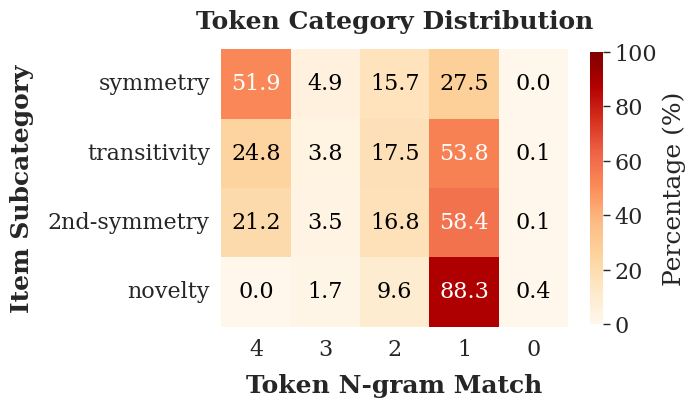

Saved: outputs/heatmap_subcategory_token_final_AmazonReviews2014-Beauty.pdf


In [21]:
# =====================================================================
# Plot 1: Conversion Heatmap  (uses: conversion_df, DATASET_ID)
# =====================================================================
import numpy as np
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt

SUB_CATS_ROWS  = ['symmetry', 'transitivity', '2nd-symmetry', 'novelty']
ORDERED_COLS   = ['4-gram', '3-gram', '2-gram', '1-gram', 'unseen']
DISPLAY_LABELS = ['4', '3', '2', '1', '0']

# --- Pivot & Normalize ---
counts = conversion_df.pivot_table(
    index='item_subcat', columns='token_cat', values='idx',
    aggfunc='nunique', fill_value=0,
)
counts = counts.reindex(index=SUB_CATS_ROWS, columns=ORDERED_COLS).fillna(0).astype(int)
pct = counts.div(counts.sum(axis=1), axis=0).replace([np.inf, -np.inf], 0).fillna(0) * 100

# --- Annotation labels ---
annot_labels = pct.copy().astype(object)
for i in range(annot_labels.shape[0]):
    for j in range(annot_labels.shape[1]):
        annot_labels.iloc[i, j] = f"{pct.iloc[i, j]:.1f}"

# --- Style ---
sns.set_context("paper")
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 14,
    'axes.labelsize': 18,  'axes.titlesize': 18,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'pdf.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    pct, annot=annot_labels, fmt="",
    cmap='OrRd',
    cbar_kws={'label': 'Percentage (%)', 'shrink': 0.5},
    linewidths=0,
    annot_kws={"size": 16, "weight": "normal"},
    ax=ax, square=True,
    vmin=0, vmax=100,
    xticklabels=DISPLAY_LABELS,
)

for text in ax.texts:
    try:
        if float(text.get_text()) > 40:
            text.set_color('white')
        else:
            text.set_color('black')
    except ValueError:
        pass

ax.set_title('Token Category Distribution', pad=15, fontweight='bold')
ax.set_xlabel('Token N-gram Match', fontweight='bold', labelpad=10)
ax.set_ylabel('Item Subcategory', fontweight='bold', labelpad=10)
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()

os.makedirs('outputs', exist_ok=True)
out_path = f"outputs/heatmap_subcategory_token_final_{DATASET_ID}.pdf"
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {out_path}")

### Plot 2: Generalization vs Raw Prefix Count

X-axis: Raw prefix transition count C(p(u)→p(v)), binned (zero bin + quantile bins).  
Y-axis: Mean NDCG@10 for TIGER and SASRec.  
Color: N-gram depth.  Point opacity: bin count.

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 48 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'G', 'I', 'M', 'N', 'P', 'R', 'S', 'T', 'a', 'at', 'c', 'e', 'f', 'five', 'g', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'w', 'x', 'z', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 19, 20, 21, 22, 24, 25, 26, 28, 35, 36, 38, 39, 40, 42, 44, 48, 49, 51, 53, 54, 55, 68, 70, 72, 73, 74, 76, 79, 80, 81, 82, 83, 85, 86, 

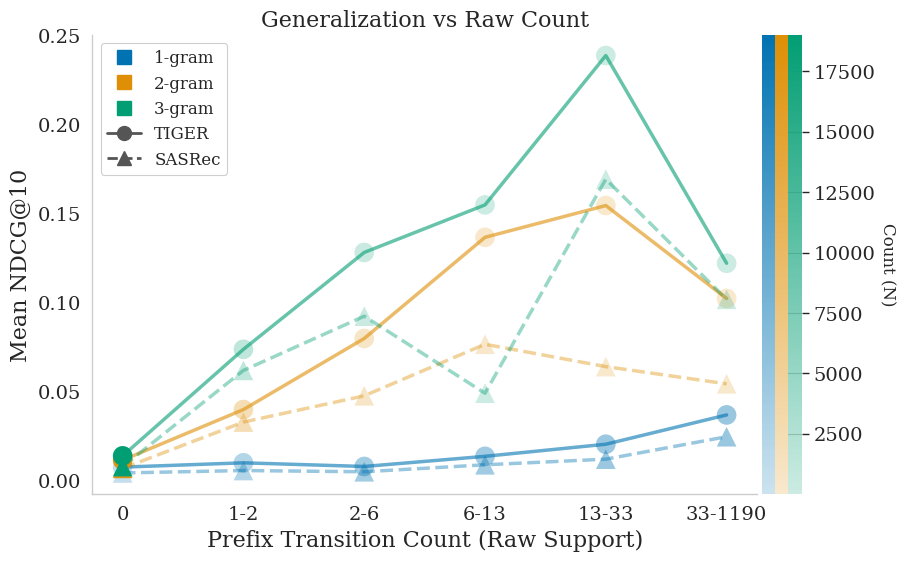

Saved: outputs/gen_raw_count_final_AmazonReviews2014-Beauty.pdf


In [22]:
# =====================================================================
# Plot 2: Generalization vs Raw Count  (uses: df_raw, DEPTHS, DATASET_ID)
# =====================================================================
import numpy as np
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Binning & Aggregation ---
df_zero = df_raw[df_raw['raw_count'] == 0].copy()
df_pos  = df_raw[df_raw['raw_count'] > 0].copy()

df_zero['bin_idx']       = 0
df_zero['bin_val_label'] = "0"

N_POS_BINS = 5
if len(df_pos) > 0:
    df_pos['bin_code'], bins = pd.qcut(
        df_pos['raw_count'], q=N_POS_BINS,
        duplicates='drop', retbins=True, labels=False,
    )
    unique_codes = sorted(df_pos['bin_code'].unique())
    code_to_idx  = {code: i + 1 for i, code in enumerate(unique_codes)}

    def _format_range_raw(code):
        lo = int(bins[int(code)])
        hi = int(bins[int(code) + 1])
        return f"{lo}" if lo == hi else f"{lo}-{hi}"

    df_pos['bin_val_label'] = df_pos['bin_code'].map(_format_range_raw)
    df_pos['bin_idx']       = df_pos['bin_code'].map(code_to_idx)
    df_final = pd.concat([df_zero, df_pos], ignore_index=True)
else:
    df_final = df_zero

agg = (
    df_final.groupby(['prefix_len', 'bin_idx', 'bin_val_label'])
    .agg(n=('raw_count', 'size'),
         ndcg_tiger=('ndcg_tiger', 'mean'),
         ndcg_sasrec=('ndcg_sasrec', 'mean'))
    .reset_index()
)

# Correct zero-bin counts
for k in DEPTHS:
    total_k = len(df_raw[df_raw['prefix_len'] == k])
    sub     = agg[agg['prefix_len'] == k]
    pos_n   = sub[sub['bin_idx'] > 0]['n'].sum()
    agg.loc[(agg['prefix_len'] == k) & (agg['bin_idx'] == 0), 'n'] = total_k - pos_n

agg = agg.sort_values(['prefix_len', 'bin_idx'])
n_min, n_max = agg['n'].min(), agg['n'].max()
agg['alpha'] = (0.2 + 0.8 * (agg['n'] - n_min) / (n_max - n_min)).fillna(1.0).clip(0.2, 1.0)

# --- Plotting ---
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 16, 'axes.titlesize': 16,
    'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 12,
})

colors    = sns.color_palette('colorblind', len(DEPTHS))
markers   = {'TIGER': 'o', 'SASRec': '^'}
line_w    = 2.5
marker_sz = 200

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

x_map    = agg[['bin_idx', 'bin_val_label']].drop_duplicates().sort_values('bin_idx')
x_ticks  = x_map['bin_idx'].values
x_labels = x_map['bin_val_label'].values

for i, k in enumerate(sorted(DEPTHS)):
    sub = agg[(agg['prefix_len'] == k) & (agg['n'] > 0)]
    if sub.empty:
        continue
    ax.plot(sub['bin_idx'], sub['ndcg_tiger'],  color=colors[i], lw=line_w, alpha=0.6)
    ax.plot(sub['bin_idx'], sub['ndcg_sasrec'], color=colors[i], lw=line_w, ls='--', alpha=0.4)
    ax.scatter(sub['bin_idx'], sub['ndcg_tiger'],  color=colors[i], marker='o',
               s=marker_sz, alpha=sub['alpha'], edgecolors='none', zorder=10)
    ax.scatter(sub['bin_idx'], sub['ndcg_sasrec'], color=colors[i], marker='^',
               s=marker_sz, alpha=sub['alpha'], edgecolors='none', zorder=10)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Prefix Transition Count (Raw Support)')
ax.set_ylabel('Mean NDCG@10')
ax.set_title('Generalization vs Raw Count')

# Legend
legend_handles = []
for i, k in enumerate(sorted(DEPTHS)):
    legend_handles.append(
        mlines.Line2D([], [], color=colors[i], marker='s', linestyle='None',
                      markersize=10, label=f'{k}-gram'))
neutral = '#555555'
legend_handles.append(mlines.Line2D([], [], color=neutral, marker='o', linestyle='-',
                                    linewidth=2, markersize=10, label='TIGER'))
legend_handles.append(mlines.Line2D([], [], color=neutral, marker='^', linestyle='--',
                                    linewidth=2, markersize=10, label='SASRec'))
ax.legend(handles=legend_handles, loc='upper left', ncol=1, frameon=True, framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Right-side alpha colorbars
divider = make_axes_locatable(ax)
caxes = [divider.append_axes("right", size="2%", pad=0.05 if j == 0 else 0.0)
         for j in range(len(DEPTHS))]
norm = mcolors.Normalize(vmin=n_min, vmax=n_max)
for i, cax in enumerate(caxes):
    c_rgb = colors[i]
    cmap_c = mcolors.LinearSegmentedColormap.from_list(
        f"a{i}", [(*c_rgb, 0.2), (*c_rgb, 1.0)])
    sm = plt.cm.ScalarMappable(cmap=cmap_c, norm=norm); sm.set_array([])
    cb = fig.colorbar(sm, cax=cax, orientation='vertical')
    cb.outline.set_visible(False)
    if i < len(DEPTHS) - 1:
        cax.set_xticks([]); cax.set_yticks([])
    else:
        cax.yaxis.set_ticks_position('right')
        cb.set_label('Count (N)', rotation=270, labelpad=15, fontsize=12)

os.makedirs('outputs', exist_ok=True)
out_path = f"outputs/gen_raw_count_final_{DATASET_ID}.pdf"
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")

### Plot 3: Purity Heatmap (TIGER Advantage)

X-axis: Prefix Purity P(p(v)|p(u)), quantile-binned.  
Y-axis: Item Purity P(v|u), quantile-binned.  
Color: Mean Δ NDCG@10 (TIGER − SASRec).  Memorization instances only.

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 32 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'D', 'E', 'G', 'I', 'P', 'R', 'T', 'a', 'bar', 'd', 'e', 'f', 'g', 'h', 'i', 'm', 'n', 'nonmarkingreturn', 'p', 'parenleft', 'parenright', 'r', 'space', 't', 'two', 'u', 'v', 'x', 'y']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 21, 36, 39, 40, 42, 44, 51, 53, 55, 68, 71, 72, 73, 74, 75, 76, 80, 81, 83, 85, 87, 88, 89, 91, 92, 95]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 35 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'D', 'E', 'G', 'I', 

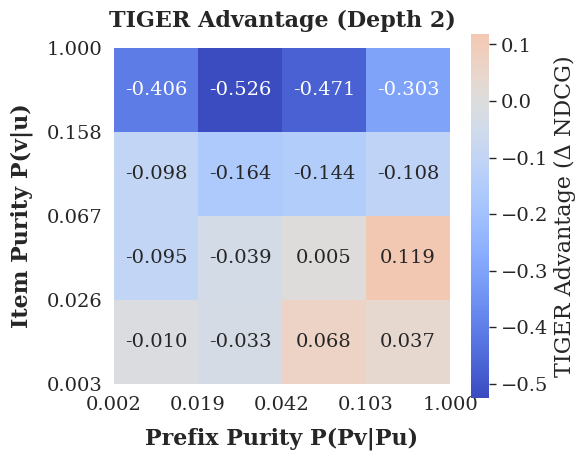

Saved: outputs/heatmap_purity_boundary_iclr_AmazonReviews2014-Beauty.pdf


In [23]:
# =====================================================================
# Plot 3: Purity Heatmap  (uses: df_heat, TARGET_K, DATASET_ID)
# =====================================================================
import numpy as np
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt

N_BINS = 4

# --- X-Axis binning (Prefix Purity) ---
try:
    df_heat['prefix_bin_id'], x_bins = pd.qcut(
        df_heat['prefix_purity'], q=N_BINS,
        duplicates='drop', labels=False, retbins=True,
    )
except ValueError:
    df_heat['prefix_bin_id'], x_bins = pd.cut(
        df_heat['prefix_purity'], bins=N_BINS,
        labels=False, retbins=True,
    )

# --- Y-Axis binning (Item Purity) ---
try:
    df_heat['item_bin_id'], y_bins = pd.qcut(
        df_heat['item_purity'], q=N_BINS,
        duplicates='drop', labels=False, retbins=True,
    )
except ValueError:
    df_heat['item_bin_id'], y_bins = pd.cut(
        df_heat['item_purity'], bins=N_BINS,
        labels=False, retbins=True,
    )

# --- Pivot ---
pivot_table = df_heat.pivot_table(
    index='item_bin_id', columns='prefix_bin_id',
    values='delta', aggfunc='mean',
)
count_table = df_heat.pivot_table(
    index='item_bin_id', columns='prefix_bin_id',
    values='delta', aggfunc='size',
)

n_x_bins = len(x_bins) - 1
n_y_bins = len(y_bins) - 1
x_indices = np.arange(n_x_bins)
y_indices = np.arange(n_y_bins)

pivot_table = pivot_table.reindex(columns=x_indices).reindex(index=y_indices[::-1])
count_table = count_table.reindex(columns=x_indices).reindex(index=y_indices[::-1])

# --- Annotations ---
annot_labels = pivot_table.copy().astype(object)
for i in range(annot_labels.shape[0]):
    for j in range(annot_labels.shape[1]):
        val   = pivot_table.iloc[i, j]
        count = count_table.iloc[i, j]
        annot_labels.iloc[i, j] = f"{val:.3f}" if (not pd.isna(val) and count > 0) else ""

mask = count_table.isnull() | (count_table == 0)

# --- Style ---
sns.set_context("paper")
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 14,
    'axes.labelsize': 16, 'axes.titlesize': 16,
    'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'pdf.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(6, 5.5))
sns.heatmap(
    pivot_table, annot=annot_labels, fmt="",
    cmap="coolwarm", center=0, mask=mask,
    linewidths=0,
    cbar_kws={'label': 'TIGER Advantage (Δ NDCG)', 'shrink': 0.8},
    annot_kws={"size": 14, "weight": "normal"},
    ax=ax, square=True,
    xticklabels=False, yticklabels=False,
)

# Boundary ticks
ax.set_xticks(np.arange(len(x_bins)))
ax.set_xticklabels([f"{x:.3f}" for x in x_bins], rotation=0)
ax.set_yticks(np.arange(len(y_bins)))
ax.set_yticklabels([f"{y:.3f}" for y in y_bins[::-1]], rotation=0)

ax.set_title(f'TIGER Advantage (Depth {TARGET_K})', pad=15, fontweight='bold')
ax.set_ylabel('Item Purity P(v|u)', fontweight='bold', labelpad=10)
ax.set_xlabel('Prefix Purity P(Pv|Pu)', fontweight='bold', labelpad=10)
plt.tight_layout()

os.makedirs('outputs', exist_ok=True)
out_path = f"outputs/heatmap_purity_boundary_iclr_{DATASET_ID}.pdf"
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {out_path}")

### Plot 4: MSP Score vs Memorization & Performance

Left axis (bars): Memorization concentration (%) per MSP percentile bin.
Right axis (lines): Mean NDCG@10 for TIGER and SASRec.
Uses pre-computed `df_msp_bins`.

Loaded df_msp_bins: 4 bins, overall memo ratio: 0.0861


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 52 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'a', 'arrowright', 'at', 'c', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'percent', 'period', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'w', 'y', 'z', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 16, 17, 19, 20, 21, 22, 23, 24, 25, 27, 35, 36, 37, 38, 39, 40, 42, 43, 44, 47, 48, 49, 51, 53, 54, 55, 68

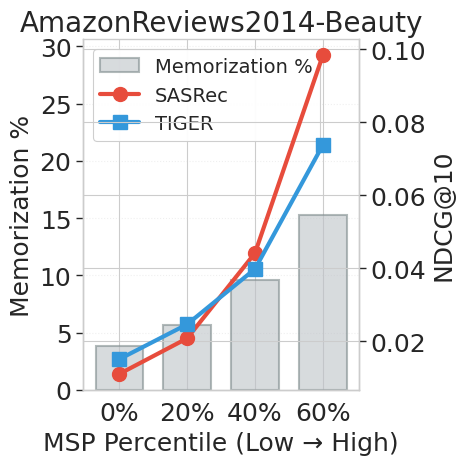

Saved: outputs/msp_memo_link_AmazonReviews2014-Beauty.pdf


In [24]:
# =====================================================================
# Plot 4: MSP Score vs Memorization & Performance
#         (uses: df_msp_bins loaded from outputs/)
# =====================================================================
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load pre-computed data ---
SPLIT = 'test'
OUTPUTS_DIR = 'outputs'
pfx = f"{OUTPUTS_DIR}/token_mem_{DATASET_ID}_{SPLIT}"
df_msp_bins = pd.read_csv(f"{pfx}_df_msp_bins.csv")
memo_ratio_overall = df_msp_bins['memo_ratio_overall'].iloc[0]
print(f"Loaded df_msp_bins: {len(df_msp_bins)} bins, overall memo ratio: {memo_ratio_overall:.4f}")

# --- Style ---
sns.set_context("paper")
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 18,
    'axes.labelsize': 18, 'axes.titlesize': 20,
    'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'pdf.fonttype': 42,
})

fig, ax1 = plt.subplots(figsize=(5, 5))

x_pos = df_msp_bins['bin']

# Left axis: memorization concentration bars
ax1.bar(
    x_pos, df_msp_bins['memo_ratio'] * 100,
    color='#bdc3c7', alpha=0.6, width=0.7,
    edgecolor='#7f8c8d', linewidth=1.5,
    label='Memorization %',
)
ax1.set_xlabel('MSP Percentile (Low → High)', fontsize=18)
ax1.set_ylabel('Memorization %', fontsize=18)
ax1.tick_params(axis='y', labelsize=18)
ax1.set_ylim(0, df_msp_bins['memo_ratio'].max() * 200)
ax1.grid(axis='y', linestyle=':', alpha=0.3)

# Right axis: performance lines
ax2 = ax1.twinx()
ax2.plot(x_pos, df_msp_bins['sas_ndcg'], color='#e74c3c', marker='o', lw=3, ms=10, label='SASRec')
ax2.plot(x_pos, df_msp_bins['tiger_ndcg'], color='#3498db', marker='s', lw=3, ms=10, label='TIGER')
ax2.set_ylabel('NDCG@10', fontsize=18)
ax2.tick_params(axis='y', labelsize=18)

# X-axis tick labels: 0%, 20%, 40%, 60%, 100% at bin boundaries
ax1.set_xticks(x_pos)
pct_labels = ['0%', '20%', '40%', '60%', '100%'][:len(x_pos)]
ax1.set_xticklabels(pct_labels, fontsize=18)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=14, frameon=True, framealpha=0.95)

ax1.set_title(f'{DATASET_ID}', fontsize=20)
ax1.spines['top'].set_visible(False)

plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
out_path = f"outputs/msp_memo_link_{DATASET_ID}.pdf"
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {out_path}")

---
## Combined Multi-Dataset Plots

These cells produce multi-panel figures combining results across datasets.
Each cell loads pre-computed data from `outputs/` — only requires cells 0–1 (imports, config).

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 49 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'L', 'M', 'N', 'O', 'P', 'S', 'T', 'Y', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'percent', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'y', 'z', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 37, 47, 48, 49, 50, 51, 54, 55, 60, 68, 70, 71, 72, 73, 74, 75, 76, 78, 79, 

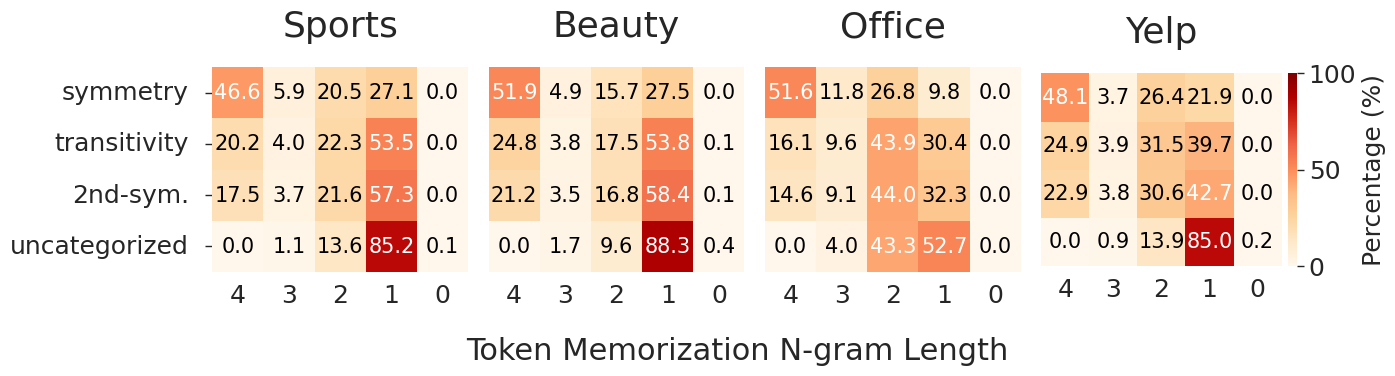

Saved: outputs/combined_conversion_heatmap.pdf


In [32]:
# =====================================================================
# Combined Plot 1: Conversion Heatmap (4 datasets)
# Shared left y-axis, shared right colorbar
# =====================================================================
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

DATASETS_P1 = [
    "AmazonReviews2014-Sports_and_Outdoors",
    "AmazonReviews2014-Beauty",
    "AmazonReviews2023-Office_Products",
    "Yelp-Yelp_2020",
]
NAMES_P1 = ["Sports", "Beauty", "Office", "Yelp"]
SPLIT = 'test'
OUTPUTS_DIR = 'outputs'

SUB_CATS_ROWS = ['symmetry', 'transitivity', '2nd-symmetry', 'novelty']
DISPLAY_ROW_LABELS = ['symmetry', 'transitivity', '2nd-sym.', 'uncategorized']
ORDERED_COLS  = ['4-gram', '3-gram', '2-gram', '1-gram', 'unseen']
COL_LABELS    = ['4', '3', '2', '1', '0']

# --- Load & compute percentage tables ---
pct_list = []
for did in DATASETS_P1:
    pfx = f"{OUTPUTS_DIR}/token_mem_{did}_{SPLIT}"
    cdf = pd.read_csv(f"{pfx}_conversion_df.csv")
    cts = cdf.pivot_table(
        index='item_subcat', columns='token_cat', values='idx',
        aggfunc='nunique', fill_value=0,
    )
    cts = cts.reindex(index=SUB_CATS_ROWS, columns=ORDERED_COLS).fillna(0).astype(int)
    pct = cts.div(cts.sum(axis=1), axis=0).replace([np.inf, -np.inf], 0).fillna(0) * 100
    pct_list.append(pct)

# --- Style ---
sns.set_context("paper")
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 22,
    'axes.labelsize': 18, 'axes.titlesize': 18,
    'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'pdf.fonttype': 42,
})

# --- Figure: 4 heatmaps + colorbar appended to last ---
fig = plt.figure(figsize=(14, 3.2))
gs = GridSpec(1, 4, width_ratios=[1, 1, 1, 1], wspace=0.08, figure=fig)

last_ax = None
for ci in range(len(DATASETS_P1)):
    ax = fig.add_subplot(gs[0, ci])
    pct = pct_list[ci]

    # Build annotation strings
    annot = pct.copy().astype(object)
    for i in range(annot.shape[0]):
        for j in range(annot.shape[1]):
            annot.iloc[i, j] = f"{pct.iloc[i, j]:.1f}"

    show_y = (ci == 0)
    sns.heatmap(
        pct, annot=annot, fmt="", cmap='OrRd',
        cbar=False, linewidths=0,
        annot_kws={"size": 15},
        ax=ax, square=True, vmin=0, vmax=100,
        xticklabels=COL_LABELS, yticklabels=DISPLAY_ROW_LABELS if show_y else False,
    )
    last_ax = ax

    # White text on dark cells
    for t in ax.texts:
        try:
            if float(t.get_text()) > 40:
                t.set_color('white')
            else:
                t.set_color('black')
        except ValueError:
            pass

    ax.set_title(NAMES_P1[ci], pad=22, fontsize=26)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(left=show_y, axis='y', pad=12)
    plt.sca(ax)
    plt.yticks(rotation=0)
    plt.xticks(rotation=0)

# Shared x-label (centered under whole figure)
fig.text(0.5, -0.10, 'Token Memorization N-gram Length', ha='center', fontsize=22)

# Shared colorbar (same height as heatmap)
divider = make_axes_locatable(last_ax)
cax = divider.append_axes("right", size="4%", pad=0.06)
sm = plt.cm.ScalarMappable(cmap=plt.cm.OrRd, norm=mpl.colors.Normalize(0, 100))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.outline.set_visible(False)
cb.set_label('Percentage (%)', fontsize=18)

os.makedirs('outputs', exist_ok=True)
out_path = "outputs/combined_conversion_heatmap.pdf"
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {out_path}")

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 45 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'I', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'at', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 35, 36, 37, 38, 39, 40, 42, 44, 49, 50, 51, 53, 54, 55, 68, 70, 72, 73, 74, 76, 80, 81, 82, 85, 86, 87, 88, 91, 92]
INFO:fontTool

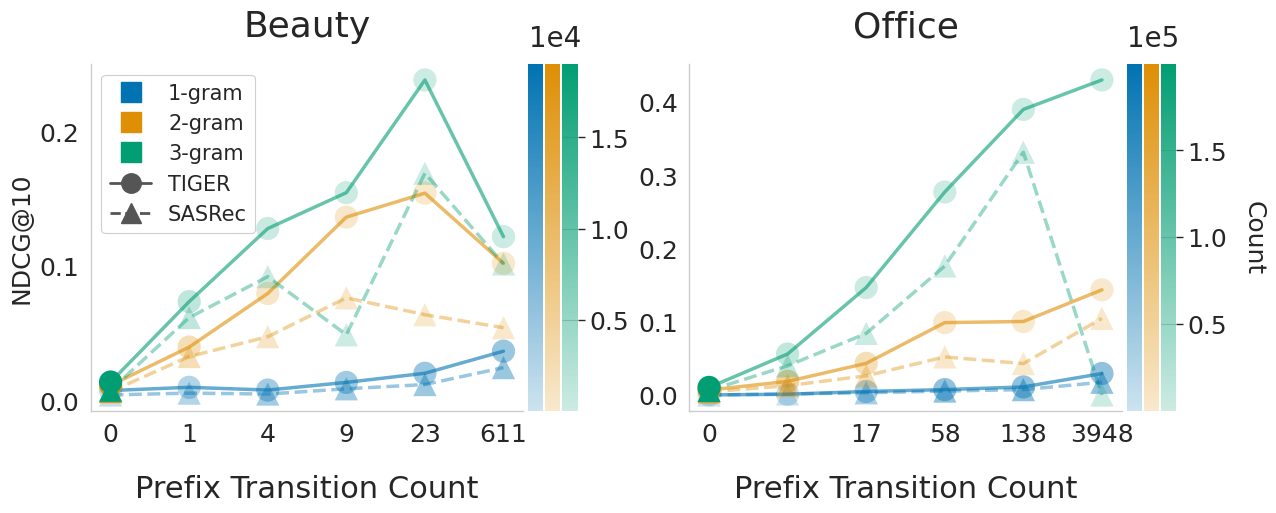

Saved: outputs/combined_gen_raw_count.pdf


In [26]:
# =====================================================================
# Combined Plot 2: Generalization vs Raw Prefix Count (2 datasets)
# Separate left y-axes, separate right colorbars
# =====================================================================
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from matplotlib.ticker import FuncFormatter, MultipleLocator, FormatStrFormatter
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

DATASETS_P2 = [
    "AmazonReviews2014-Beauty",
    "AmazonReviews2023-Office_Products",
]
NAMES_P2 = ["Beauty", "Office"]
SPLIT = 'test'
OUTPUTS_DIR = 'outputs'
N_POS_BINS = 5

# --- Style ---
sns.set_context("paper")
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    # 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 18, 'axes.titlesize': 18,
    'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'legend.fontsize': 18,
})



fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.subplots_adjust(wspace=0.23)

for pi, (ax, did, name) in enumerate(zip(axes, DATASETS_P2, NAMES_P2)):
    # Load data & metadata
    pfx = f"{OUTPUTS_DIR}/token_mem_{did}_{SPLIT}"
    df_raw = pd.read_csv(f"{pfx}_df_raw.csv")
    with open(f"{pfx}_meta.json") as f:
        meta = json.load(f)
    DEPTHS = meta['DEPTHS']
    colors = sns.color_palette('colorblind', len(DEPTHS))

    # --- Binning: zero bin + quantile bins for positive counts ---
    df_zero = df_raw[df_raw['raw_count'] == 0].copy()
    df_pos  = df_raw[df_raw['raw_count'] > 0].copy()
    df_zero['bin_idx'] = 0
    df_zero['bin_val_label'] = "0"

    if len(df_pos) > 0:
        df_pos['bin_code'], bins = pd.qcut(
            df_pos['raw_count'], q=N_POS_BINS,
            duplicates='drop', retbins=True, labels=False,
        )
        unique_codes = sorted(df_pos['bin_code'].unique())
        code_to_idx = {c: i + 1 for i, c in enumerate(unique_codes)}

        def _fmt(code, _bins=bins):
            lo, hi = int(_bins[int(code)]), int(_bins[int(code) + 1])
            mid = (lo + hi) / 2
            return f"{int(mid)}"

        df_pos['bin_val_label'] = df_pos['bin_code'].map(_fmt)
        df_pos['bin_idx']       = df_pos['bin_code'].map(code_to_idx)
        df_final = pd.concat([df_zero, df_pos], ignore_index=True)
    else:
        df_final = df_zero

    agg = (
        df_final.groupby(['prefix_len', 'bin_idx', 'bin_val_label'])
        .agg(n=('raw_count', 'size'),
             ndcg_tiger=('ndcg_tiger', 'mean'),
             ndcg_sasrec=('ndcg_sasrec', 'mean'))
        .reset_index()
    )

    # Correct zero-bin counts
    for k in DEPTHS:
        total_k = len(df_raw[df_raw['prefix_len'] == k])
        pos_n   = agg[(agg['prefix_len'] == k) & (agg['bin_idx'] > 0)]['n'].sum()
        agg.loc[(agg['prefix_len'] == k) & (agg['bin_idx'] == 0), 'n'] = total_k - pos_n

    agg = agg.sort_values(['prefix_len', 'bin_idx'])
    n_min, n_max = agg['n'].min(), agg['n'].max()
    agg['alpha'] = (0.2 + 0.8 * (agg['n'] - n_min) / max(n_max - n_min, 1)).clip(0.2, 1.0)

    # --- Plot lines + scatter ---
    lw, ms = 2.5, 280
    x_map = agg[['bin_idx', 'bin_val_label']].drop_duplicates().sort_values('bin_idx')

    for i, k in enumerate(sorted(DEPTHS)):
        sub = agg[(agg['prefix_len'] == k) & (agg['n'] > 0)]
        if sub.empty:
            continue
        ax.plot(sub['bin_idx'], sub['ndcg_tiger'],  color=colors[i], lw=lw, alpha=0.6)
        ax.plot(sub['bin_idx'], sub['ndcg_sasrec'], color=colors[i], lw=lw, ls='--', alpha=0.4)
        ax.scatter(sub['bin_idx'], sub['ndcg_tiger'],  color=colors[i], marker='o',
                   s=ms, alpha=sub['alpha'], edgecolors='none', zorder=10)
        ax.scatter(sub['bin_idx'], sub['ndcg_sasrec'], color=colors[i], marker='^',
                   s=ms, alpha=sub['alpha'], edgecolors='none', zorder=10)

    ax.set_xticks(x_map['bin_idx'].values)
    ax.set_xticklabels(x_map['bin_val_label'].values, fontsize=18)
    ax.set_xlabel('Prefix Transition Count', fontsize=22, labelpad=20)
    ax.set_ylabel('NDCG@10', fontsize=18) if pi == 0 else ax.set_ylabel('')
    ax.set_title(name, pad=20, fontsize=26)
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    # Legend (first subplot only)
    if pi == 0:
        handles = []
        for i, k in enumerate(sorted(DEPTHS)):
            handles.append(mlines.Line2D([], [], color=colors[i], marker='s',
                                         linestyle='None', markersize=14, label=f'{k}-gram'))
        handles.append(mlines.Line2D([], [], color='#555', marker='o', ls='-',
                                     lw=2, markersize=14, label='TIGER'))
        handles.append(mlines.Line2D([], [], color='#555', marker='^', ls='--',
                                     lw=2, markersize=14, label='SASRec'))
        ax.legend(handles=handles, loc='upper left', frameon=True, framealpha=0.95, fontsize=15)

    # --- Right-side alpha colorbars (per subplot) ---
    divider = make_axes_locatable(ax)
    caxes = [divider.append_axes("right", size="3.5%", pad=0.05 if j == 0 else 0.02)
             for j in range(len(DEPTHS))]
    norm = mcolors.Normalize(vmin=n_min, vmax=n_max)
    for i, cax_i in enumerate(caxes):
        c = colors[i]
        cmap_c = mcolors.LinearSegmentedColormap.from_list(
            f"a{pi}_{i}", [(*c, 0.2), (*c, 1.0)])
        sm = plt.cm.ScalarMappable(cmap=cmap_c, norm=norm)
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cax_i)
        cb.outline.set_visible(False)
        if i < len(DEPTHS) - 1:
            cax_i.set_xticks([])
            cax_i.set_yticks([])
        else:
            cax_i.yaxis.set_ticks_position('right')
            cb.ax.tick_params(labelsize=18)
            if pi == 0:
                cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e4:.1f}'))
                cb.ax.text(-0.5, 1.05, '1e4', transform=cb.ax.transAxes, fontsize=20, ha='center')
            else:
                cb.set_label('Count', rotation=270, labelpad=28, fontsize=18)
                cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e5:.1f}'))
                cb.ax.text(-0.5, 1.05, '1e5', transform=cb.ax.transAxes, fontsize=20, ha='center')

os.makedirs('outputs', exist_ok=True)
out_path = "outputs/combined_gen_raw_count.pdf"
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {out_path}")

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 6 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'phi1', 'psi', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 860, 873]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 6 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'phi1', 'psi', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 860, 873]
INFO:fontTools.subset:Closing glyph list over 'glyf': 6 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'phi1', 'psi', 'space']
INF

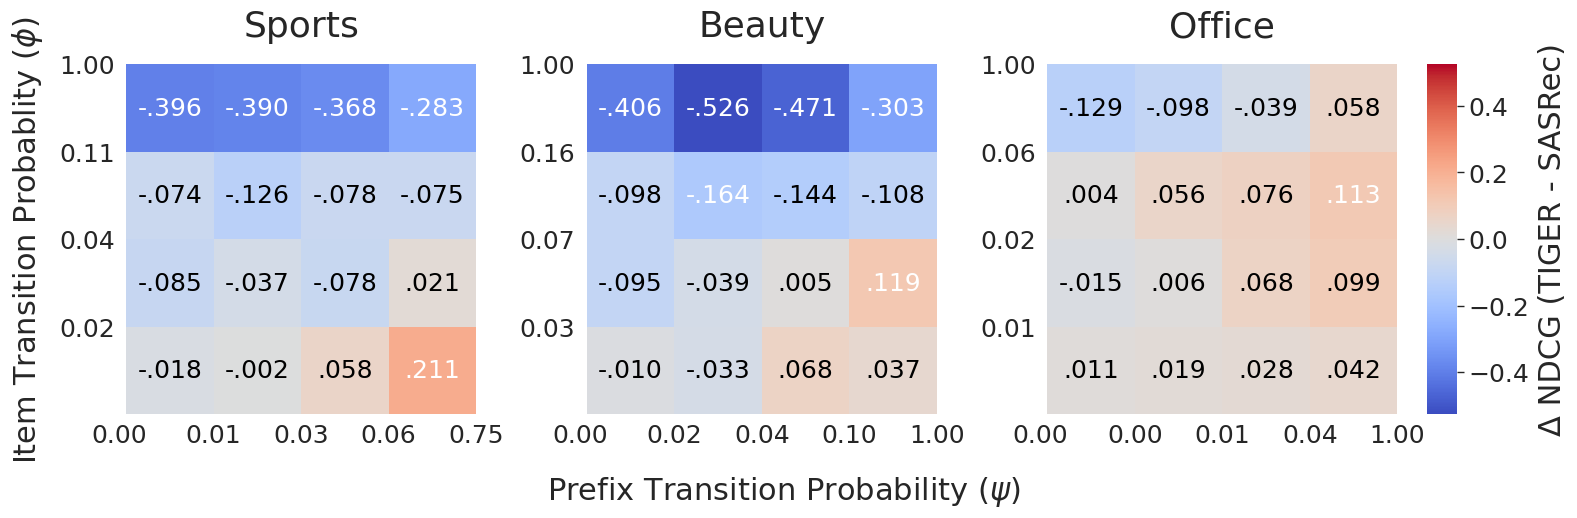

Saved: outputs/combined_purity_heatmap.pdf


In [31]:
# =====================================================================
# Combined Plot 3: Purity Heatmap — TIGER Advantage (3 datasets)
# Fixed Layout: Equal sizes, matching colorbar height
# Updated: Shared 0.00 moved left, White text threshold > 0.1 or < -0.15
# =====================================================================
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.gridspec import GridSpec
import pandas as pd
import os

DATASETS_P3 = [
    "AmazonReviews2014-Sports_and_Outdoors",
    "AmazonReviews2014-Beauty",
    "AmazonReviews2023-Office_Products",
]
NAMES_P3 = ["Sports", "Beauty", "Office"]
SPLIT = 'test'
OUTPUTS_DIR = 'outputs'
N_BINS = 4

# --- Load, bin, and pivot each dataset ---
pivots, counts_tbl, x_bins_all, y_bins_all = [], [], [], []

for did in DATASETS_P3:
    pfx = f"{OUTPUTS_DIR}/token_mem_{did}_{SPLIT}"
    df_h = pd.read_csv(f"{pfx}_df_heat.csv")

    # Prefix purity binning (x-axis)
    try:
        df_h['xbin'], xb = pd.qcut(
            df_h['prefix_purity'], q=N_BINS,
            duplicates='drop', labels=False, retbins=True)
    except ValueError:
        df_h['xbin'], xb = pd.cut(
            df_h['prefix_purity'], bins=N_BINS,
            labels=False, retbins=True)

    # Item purity binning (y-axis)
    try:
        df_h['ybin'], yb = pd.qcut(
            df_h['item_purity'], q=N_BINS,
            duplicates='drop', labels=False, retbins=True)
    except ValueError:
        df_h['ybin'], yb = pd.cut(
            df_h['item_purity'], bins=N_BINS,
            labels=False, retbins=True)

    pv = df_h.pivot_table(index='ybin', columns='xbin', values='delta', aggfunc='mean')
    ct = df_h.pivot_table(index='ybin', columns='xbin', values='delta', aggfunc='size')

    nx, ny = len(xb) - 1, len(yb) - 1
    pv = pv.reindex(columns=np.arange(nx)).reindex(index=np.arange(ny)[::-1])
    ct = ct.reindex(columns=np.arange(nx)).reindex(index=np.arange(ny)[::-1])

    pivots.append(pv)
    counts_tbl.append(ct)
    x_bins_all.append(xb)
    y_bins_all.append(yb)

# Global delta range for shared colorbar
all_vals = pd.concat([p.stack() for p in pivots]).dropna()
vabs = max(abs(all_vals.min()), abs(all_vals.max()))

# --- Style ---
sns.set_context("paper")
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 18,
    'axes.labelsize': 18, 'axes.titlesize': 18,
    'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'pdf.fonttype': 42,
})

# --- Figure Setup ---
fig = plt.figure(figsize=(15, 5))
gs = GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.2, figure=fig, 
              left=0.05, right=0.92, top=0.85, bottom=0.15)

axes = []
for ci in range(len(DATASETS_P3)):
    ax = fig.add_subplot(gs[0, ci])
    axes.append(ax)
    
    pv, ct = pivots[ci], counts_tbl[ci]
    xb, yb = x_bins_all[ci], y_bins_all[ci]

    # Build annotations
    def _fmt_val(v):
        if v == 0: return "0"
        s = f"{v:.3f}"
        if s.startswith("-0."): return "-." + s[3:]
        if s.startswith("0."): return "." + s[2:]
        return s
    
    annot = pv.copy().astype(object)
    for i in range(annot.shape[0]):
        for j in range(annot.shape[1]):
            v, c = pv.iloc[i, j], ct.iloc[i, j]
            annot.iloc[i, j] = _fmt_val(v) if (not pd.isna(v) and c > 0) else ""

    mask = ct.isnull() | (ct == 0)

    # Draw Heatmap
    hm = sns.heatmap(
        pv, annot=annot, fmt="", cmap="coolwarm",
        center=0, mask=mask, cbar=False, linewidths=0,
        annot_kws={"size": 18, "weight": "normal"}, ax=ax, square=True,
        vmin=-vabs, vmax=vabs,
        xticklabels=False, yticklabels=False,
    )

    # --- White text logic (Updated Thresholds) ---
    for text in ax.texts:
        try:
            val_text = text.get_text()
            if val_text:
                if val_text.startswith('-.'): val_float = float(val_text.replace('-.', '-0.'))
                elif val_text.startswith('.'): val_float = float(val_text.replace('.', '0.'))
                else: val_float = float(val_text.replace('−', '-'))
                
                # New Threshold: > 0.1 or < -0.15
                if val_float > 0.1 or val_float < -0.15:
                    text.set_color('white')
                else:
                    text.set_color('black')
        except:
            pass

    # --- Boundary tick labels with shared 0.00 ---
    xtick_labels = [f"{v:.2f}" for v in xb]
    ytick_labels = [f"{v:.2f}" for v in yb[::-1]]
    
    # Hide the corner labels
    xtick_labels[0] = "" 
    ytick_labels[-1] = ""

    ax.set_xticks(np.arange(len(xb)))
    ax.tick_params(axis='x', pad=2) 
    ax.set_xticklabels(xtick_labels, rotation=0, fontsize=18)
    
    ax.set_yticks(np.arange(len(yb)))
    ax.set_yticklabels(ytick_labels, rotation=0, fontsize=18)

    # --- Shared "0.00" label moved left ---
    # Moved from -0.02 to -0.08 to align with y-axis
    ax.text(-0.02, -0.06, "0.00", transform=ax.transAxes, 
            fontsize=18, ha='center', va='center')

    ax.set_title(NAMES_P3[ci], pad=20, fontsize=26)
    if ci == 0:
        ax.set_ylabel('Item Transition Probablity ($\phi$)', fontsize=22, labelpad=10)
    else:
        ax.set_ylabel('')
    ax.set_xlabel('')

# Shared x-label
fig.text(0.5, -0.02, 'Prefix Transition Probability ($\psi$)', ha='center', fontsize=22)

# --- Manual Colorbar Placement ---
pos = axes[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])

norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vabs, vmax=vabs)
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.outline.set_visible(False)
cb.set_label('Δ NDCG (TIGER - SASRec)', fontsize=22, labelpad=6)
cb.ax.tick_params(labelsize=18)

os.makedirs('outputs', exist_ok=True)
out_path = "outputs/combined_purity_heatmap.pdf"
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {out_path}")

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 46 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'I', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'a', 'at', 'c', 'e', 'f', 'five', 'four', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'percent', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'y', 'z', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 17, 19, 20, 21, 22, 23, 24, 25, 26, 35, 36, 37, 38, 39, 40, 42, 44, 48, 49, 50, 51, 52, 53, 54, 55, 68, 70, 72, 73, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88, 92, 93]
INFO:fontTo

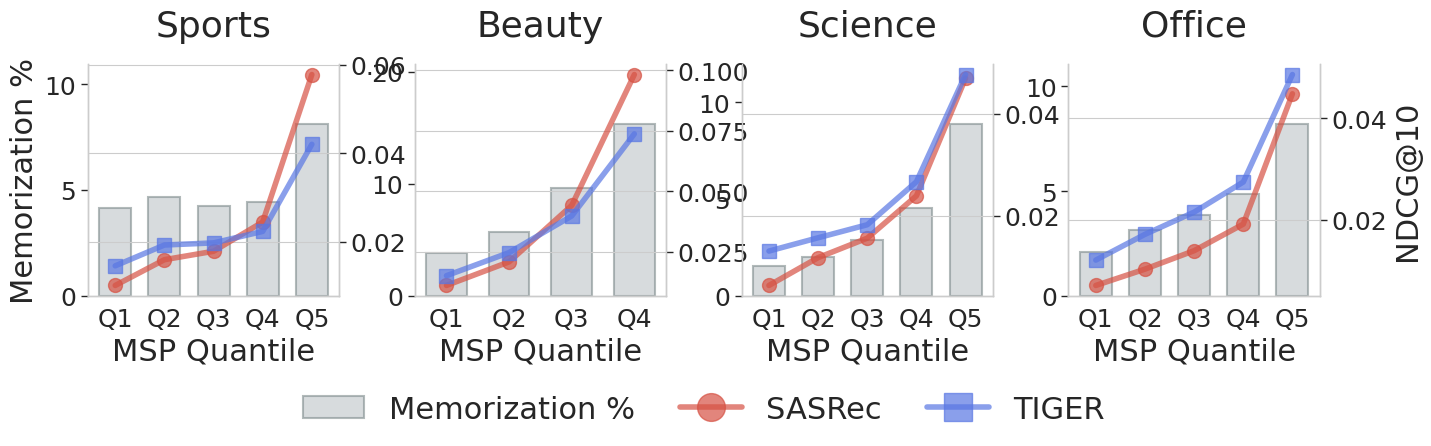

Saved: outputs/combined_msp_memo_final_compact.pdf


In [28]:
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# =====================================================================
# Configuration
# =====================================================================
DATASETS_P4 = [
    "AmazonReviews2014-Sports_and_Outdoors",
    "AmazonReviews2014-Beauty",
    "AmazonReviews2023-Industrial_and_Scientific",
    "AmazonReviews2023-Office_Products",
]
NAMES_P4 = ["Sports", "Beauty", "Science", "Office"]
SPLIT = 'test'
OUTPUTS_DIR = 'outputs'

# --- Colors (Coolwarm +- 0.4 from center 0.5) ---
cmap = plt.cm.coolwarm
color_tiger = cmap(0.1)  # Cool Blue (0.5 - 0.4)
color_sasrec = cmap(0.9) # Warm Red (0.5 + 0.4)
BAR_COLOR = '#bdc3c7'
BAR_EDGE = '#7f8c8d'

# --- Style ---
sns.set_context("paper")
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 18,
    'axes.labelsize': 22,      # Axis Names
    'axes.titlesize': 26,      # Subplot Titles
    'xtick.labelsize': 18,     # Tick Labels
    'ytick.labelsize': 18,
    'legend.fontsize': 22,     # Legend Text
    'pdf.fonttype': 42,
})

# =====================================================================
# Plotting
# =====================================================================
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
# Compact width space
fig.subplots_adjust(wspace=0.3, bottom=0.3, left=0.06, right=0.94)

legend_handles = []
legend_labels = []

for pi, (ax1, did, name) in enumerate(zip(axes, DATASETS_P4, NAMES_P4)):
    # 1. Load Data
    pfx = f"{OUTPUTS_DIR}/token_mem_{did}_{SPLIT}"
    if not os.path.exists(f"{pfx}_df_msp_bins.csv"):
        # Dummy data for validation
        print(f"Warning: {pfx}_df_msp_bins.csv not found. Using dummy data.")
        # Create 5 bins for Q1-Q5
        df_bins = pd.DataFrame({
            'bin': range(5),
            'memo_ratio': np.random.rand(5) * 0.8,
            'sas_ndcg': np.sort(np.random.rand(5) * 0.1),
            'tiger_ndcg': np.sort(np.random.rand(5) * 0.12)
        })
        x_pos = range(5)
    else:
        df_bins = pd.read_csv(f"{pfx}_df_msp_bins.csv")
        # Ensure we restrict or re-bin to 5 if the file has more
        if len(df_bins) != 5:
             # Basic check: if data isn't 5 rows, just take first 5 or re-index
             # Ideally your pre-processing script generated 5 bins.
             df_bins = df_bins.iloc[:5]
        x_pos = range(len(df_bins))

    # 2. Left Axis: Memorization Bar
    bars = ax1.bar(
        x_pos, df_bins['memo_ratio'] * 100,
        color=BAR_COLOR, alpha=0.6, width=0.65,
        edgecolor=BAR_EDGE, linewidth=1.5,
        label='Memorization %'
    )
    
    # Y-Axis Label (only on first plot)
    if pi == 0:
        ax1.set_ylabel('Memorization %')
    else:
        ax1.set_ylabel('')
        
    ax1.set_xlabel('MSP Quantile')
    ax1.set_ylim(0, df_bins['memo_ratio'].max() * 100 * 1.35) 
    ax1.grid(False)
    
    # 3. Right Axis: Performance Lines
    ax2 = ax1.twinx()
    
    # Line 1: SASRec (Red)
    l1, = ax2.plot(
        x_pos, df_bins['sas_ndcg'], 
        color=color_sasrec, alpha=0.7, 
        marker='o', lw=4, ms=10,  # Thicker lines and markers
        label='SASRec'
    )
    
    # Line 2: TIGER (Blue)
    l2, = ax2.plot(
        x_pos, df_bins['tiger_ndcg'], 
        color=color_tiger, alpha=0.7, 
        marker='s', lw=4, ms=10, 
        label='TIGER'
    )

    if pi == len(DATASETS_P4) - 1:
        ax2.set_ylabel('NDCG@10')
    else:
        ax2.set_ylabel('')
        
    # 4. Ticks & Spines
    ax1.set_xticks(x_pos)
    # Quantile Labels Q1-Q5
    q_labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
    if len(x_pos) <= len(q_labels):
        ax1.set_xticklabels(q_labels[:len(x_pos)])
    
    ax1.set_title(name, pad=20)
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    # Collect handles for global legend
    if pi == 0:
        legend_handles = [bars, l1, l2]
        legend_labels = ['Memorization %', 'SASRec', 'TIGER']

# =====================================================================
# Global Legend
# =====================================================================
fig.legend(
    legend_handles, 
    legend_labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    markerscale=2.0, # Make markers in legend larger
    frameon=False,
    borderaxespad=0,
    columnspacing=1.5 # Space out legend items
)

os.makedirs('outputs', exist_ok=True)
out_path = "outputs/combined_msp_memo_final_compact.pdf"
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {out_path}")

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 46 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'I', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'a', 'at', 'c', 'e', 'eight', 'f', 'five', 'four', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'percent', 'period', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'y', 'z', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 17, 19, 20, 21, 22, 23, 24, 25, 27, 35, 36, 37, 38, 39, 40, 42, 44, 48, 49, 50, 51, 52, 53, 54, 55, 68, 70, 72, 73, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88, 92, 93]
INFO:fontTo

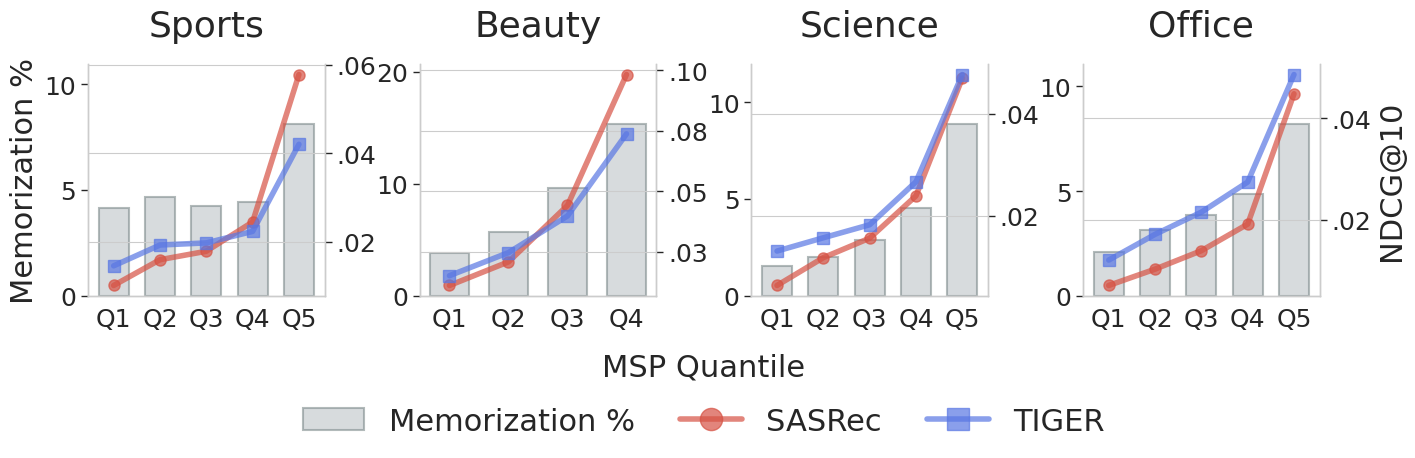

Saved: outputs/combined_msp_memo.pdf


In [29]:
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from matplotlib.ticker import FuncFormatter

# =====================================================================
# Configuration
# =====================================================================
DATASETS_P4 = [
    "AmazonReviews2014-Sports_and_Outdoors",
    "AmazonReviews2014-Beauty",
    "AmazonReviews2023-Industrial_and_Scientific",
    "AmazonReviews2023-Office_Products",
]
NAMES_P4 = ["Sports", "Beauty", "Science", "Office"]
SPLIT = 'test'
OUTPUTS_DIR = 'outputs'

# --- Colors (Coolwarm +- 0.4 from center 0.5) ---
cmap = plt.cm.coolwarm
color_tiger = cmap(0.1)  # Cool Blue (0.5 - 0.4)
color_sasrec = cmap(0.9) # Warm Red (0.5 + 0.4)
BAR_COLOR = '#bdc3c7'
BAR_EDGE = '#7f8c8d'

# --- Style ---
sns.set_context("paper")
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 18,
    'axes.labelsize': 22,      # Axis Names
    'axes.titlesize': 26,      # Subplot Titles
    'xtick.labelsize': 18,     # Tick Labels
    'ytick.labelsize': 18,
    'legend.fontsize': 22,     # Legend Text
    'pdf.fonttype': 42,
})

# --- Custom Formatter to remove leading zero (e.g., 0.06 -> .06) ---
def no_leading_zero(x, pos):
    if x == 0:
        return '0'
    val_str = f"{x:.2f}"
    if val_str.startswith("0."):
        return val_str[1:]
    if val_str.startswith("-0."):
        return "-" + val_str[2:]
    return val_str

formatter = FuncFormatter(no_leading_zero)

# =====================================================================
# Plotting
# =====================================================================
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

# INCREASED WSPACE (0.3 -> 0.4) for better separation
fig.subplots_adjust(wspace=0.4, bottom=0.3, left=0.06, right=0.94)

legend_handles = []
legend_labels = []

for pi, (ax1, did, name) in enumerate(zip(axes, DATASETS_P4, NAMES_P4)):
    # 1. Load Data
    pfx = f"{OUTPUTS_DIR}/token_mem_{did}_{SPLIT}"
    if not os.path.exists(f"{pfx}_df_msp_bins.csv"):
        print(f"Warning: {pfx}_df_msp_bins.csv not found. Using dummy data.")
        df_bins = pd.DataFrame({
            'bin': range(5),
            'memo_ratio': np.random.rand(5) * 0.8,
            'sas_ndcg': np.sort(np.random.rand(5) * 0.1),
            'tiger_ndcg': np.sort(np.random.rand(5) * 0.12)
        })
        x_pos = range(5)
    else:
        df_bins = pd.read_csv(f"{pfx}_df_msp_bins.csv")
        if len(df_bins) != 5:
             df_bins = df_bins.iloc[:5]
        x_pos = range(len(df_bins))

    # 2. Left Axis: Memorization Bar
    bars = ax1.bar(
        x_pos, df_bins['memo_ratio'] * 100,
        color=BAR_COLOR, alpha=0.6, width=0.65,
        edgecolor=BAR_EDGE, linewidth=1.5,
        label='Memorization %'
    )
    
    # Y-Axis Label (only on first plot)
    if pi == 0:
        ax1.set_ylabel('Memorization %')
    else:
        ax1.set_ylabel('')
        
    # REMOVED INDIVIDUAL X-LABEL
    ax1.set_xlabel('') 
    
    ax1.set_ylim(0, df_bins['memo_ratio'].max() * 100 * 1.35) 
    ax1.grid(False)
    
    # 3. Right Axis: Performance Lines
    ax2 = ax1.twinx()
    
    # Line 1: SASRec (Red)
    l1, = ax2.plot(
        x_pos, df_bins['sas_ndcg'], 
        color=color_sasrec, alpha=0.7, 
        marker='o', lw=4, ms=8,
        label='SASRec'
    )
    
    # Line 2: TIGER (Blue)
    l2, = ax2.plot(
        x_pos, df_bins['tiger_ndcg'], 
        color=color_tiger, alpha=0.7, 
        marker='s', lw=4, ms=8, 
        label='TIGER'
    )

    # APPLY COMPACT FORMATTER TO RIGHT Y-AXIS
    ax2.yaxis.set_major_formatter(formatter)

    if pi == len(DATASETS_P4) - 1:
        ax2.set_ylabel('NDCG@10')
    else:
        ax2.set_ylabel('')
        
    # 4. Ticks & Spines
    ax1.set_xticks(x_pos)
    q_labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
    if len(x_pos) <= len(q_labels):
        ax1.set_xticklabels(q_labels[:len(x_pos)])
    
    ax1.set_title(name, pad=20)
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    if pi == 0:
        legend_handles = [bars, l1, l2]
        legend_labels = ['Memorization %', 'SASRec', 'TIGER']

# =====================================================================
# Global Elements
# =====================================================================

# SHARED X-AXIS LABEL
fig.text(0.5, 0.10, 'MSP Quantile', ha='center', fontsize=22)

# Global Legend
fig.legend(
    legend_handles, 
    legend_labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    markerscale=2.0, 
    frameon=False,
    borderaxespad=0,
    columnspacing=1.5
)

os.makedirs('outputs', exist_ok=True)
out_path = "outputs/combined_msp_memo.pdf"
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {out_path}")